In [1]:
import torch
import diffusers

In [2]:
import transformers
import cv2

In [ ]:
from diffusers import StableVideoDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
pipe=StableVideoDiffusionPipeline.from_pretrained("stabilityai/stable-video-diffusion-img2vid-xt",torch_dtype=torch.float16,variant="fp16")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

In [ ]:
pipe

StableVideoDiffusionPipeline {
  "_class_name": "StableVideoDiffusionPipeline",
  "_diffusers_version": "0.37.1",
  "_name_or_path": "stabilityai/stable-video-diffusion-img2vid-xt",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "unet": [
    "diffusers",
    "UNetSpatioTemporalConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLTemporalDecoder"
  ]
}

In [ ]:
path="santa.png"

In [ ]:
path

'santa.png'

In [ ]:
from diffusers.utils import load_image,export_to_video

In [ ]:
image=load_image(path)

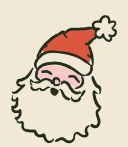

In [ ]:
image

In [ ]:
pipe.enable_model_cpu_offload()

In [ ]:
generator=torch.manual_seed(42)

In [ ]:
generator

In [ ]:
pipe.to(torch.float16)

frames = pipe(image, decode_chunk_size=8, generator=generator).frames[0]

  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
frames

[<PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image image mode=RGB size=1024x576>,
 <PIL.Image.Image im

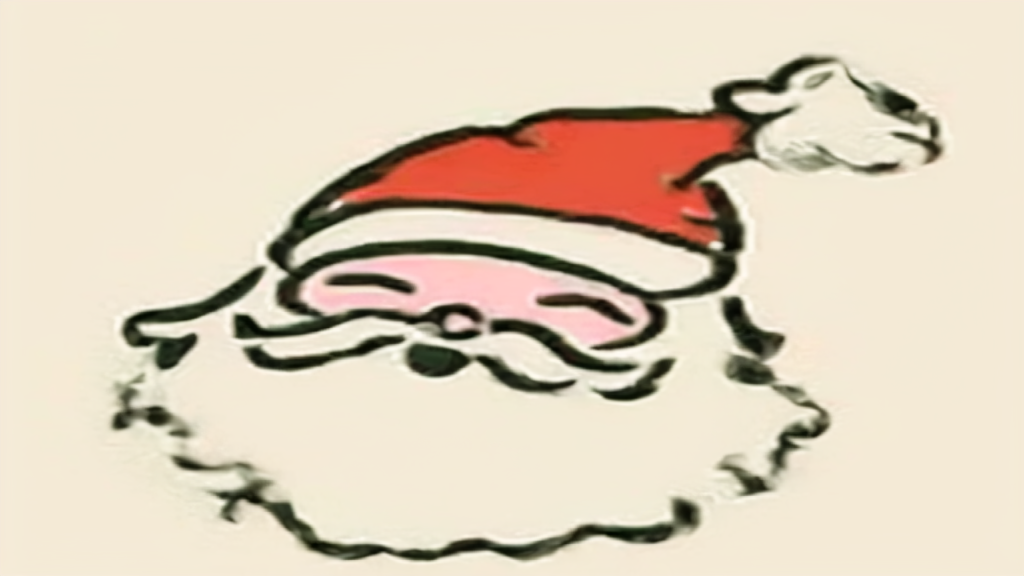

In [ ]:
frames[1]

In [ ]:
len(frames)

25

In [ ]:
export_to_video(frames,"santa.mp4",fps=7)

'santa.mp4'

In [ ]:
##generating video using another diffusion model by providing image and prompt

In [3]:
import torch
torch.cuda.empty_cache()

In [4]:
from diffusers import I2VGenXLPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [5]:
from diffusers.utils import load_image,export_to_video

In [6]:
repo_id="ali-vilab/i2vgen-xl"

In [7]:
pipeline=I2VGenXLPipeline.from_pretrained(repo_id,torch_dtype=torch.float16,variant="fp16")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

The I2VGenXLPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


In [8]:
pipeline.enable_model_cpu_offload()

In [9]:
sea=load_image("sea.jpg")

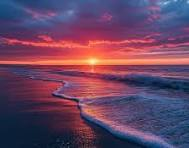

In [10]:
sea

In [11]:
prompt="the sea waves heavily"

In [12]:
generator=torch.manual_seed(42)

In [13]:
frames=pipeline(prompt=prompt,image=sea,num_frames=16,generator=generator).frames[0]

  0%|          | 0/50 [00:00<?, ?it/s]

In [14]:
frames

[<PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>,
 <PIL.Image.Image image mode=RGB size=1280x704>]

In [15]:
len(frames)

16

In [16]:
export_to_video(frames,"sea_waves.mp4",fps=4)

'sea_waves.mp4'